# Lab 2.5 – Rapid step tests + device messages

Goal: explore two bronze tables (device_messages_raw, rapid_step_tests_raw), clean distance readings, summarize per-device behavior, analyze step_points timing, and relate sensor readings to each test window.


In [0]:
%sql
SELECT 'device_messages_raw' AS table_name, COUNT(*) AS rows FROM
workspace.bronze.device_messages_raw
UNION ALL
SELECT 'rapid_step_tests_raw', COUNT(*) FROM
workspace.bronze.rapid_step_tests_raw;

SELECT * FROM workspace.bronze.rapid_step_tests_raw LIMIT 10;

customer,device_id,start_time,step_points,stop_time,test_time,token,total_steps
user@test.com,spotter-1.stedi.local,1757548577179,"List(905, 905, 904, 905, 905, 1005, 904, 805, 904, 905, 905, 1005, 804, 905, 1005, 1809, 805, 1005, 904, 905, 905, 905, 904, 905, 905, 905, 905, 905, 905, 905)",1757548599897,22718,a9a45b67-8a2e-497a-ab4c-26fb711bcfd5,30
user@test.com,spotter-1.stedi.local,1757592647584,"List(605, 605, 605, 706, 604, 605, 605, 605, 706, 604, 605, 605, 605, 605, 705, 605, 605, 605, 706, 604, 605, 605, 605, 706, 604, 605, 605, 605, 605, 605)",1757592664419,16835,26229c88-8c5c-4e88-b426-6149b854bea1,30
user@test.com,spotter-1.stedi.local,1757631541978,"List(604, 603, 604, 603, 704, 604, 603, 604, 704, 603, 604, 603, 704, 604, 603, 604, 603, 704, 603, 604, 603, 604, 1307, 604, 603, 704, 604, 604, 604, 604)",1757631559479,17501,563276ab-39b6-452e-a8e0-94ff039f0b1f,30
user@test.com,spotter-1.stedi.local,1757632889779,"List(507, 405, 506, 405, 507, 405, 506, 405, 507, 405, 506, 405, 507, 405, 506, 405, 506, 406, 506, 405, 506, 405, 507, 405, 506, 405, 456, 456, 456, 456)",1757632901628,11849,e2fc4548-01bb-4508-93b5-a80033716bbe,30
user@test.com,spotter-1.stedi.local,1757649272979,"List(604, 603, 604, 604, 705, 604, 603, 604, 705, 604, 604, 603, 604, 604, 705, 603, 604, 604, 705, 604, 603, 604, 604, 705, 604, 603, 604, 604, 604, 604)",1757649289786,16807,927b07e9-be4a-415e-8d61-36184311a90c,30
user@test.com,spotter-1.stedi.local,1757653824779,"List(506, 405, 507, 405, 506, 405, 506, 405, 506, 405, 507, 405, 506, 405, 506, 405, 506, 405, 507, 405, 506, 405, 506, 405, 506, 405, 455, 455, 455, 455)",1757653836625,11846,39c2a2f1-a683-48c7-87ab-84ca35bd267c,30
user@test.com,spotter-1.stedi.local,1757734636179,"List(904, 904, 904, 904, 905, 803, 1105, 804, 904, 905, 904, 904, 904, 1005, 803, 1005, 804, 1004, 905, 904, 804, 1004, 804, 904, 1005, 904, 904, 904, 904, 904)",1757734658884,22705,129f9191-57b8-4334-b5dc-56813d62d8c8,30
user@test.com,spotter-1.stedi.local,1757970875979,"List(605, 604, 605, 705, 604, 605, 604, 604, 706, 604, 605, 604, 604, 706, 604, 604, 605, 604, 706, 604, 604, 605, 604, 705, 605, 604, 605, 604, 604, 604)",1757970892803,16824,ca0ba820-5457-46f7-a11e-f67e5fcd663f,30
user@test.com,spotter-1.stedi.local,1757973390778,"List(505, 403, 505, 403, 505, 403, 505, 403, 505, 404, 504, 404, 504, 404, 504, 404, 504, 404, 504, 404, 504, 404, 504, 404, 504, 505, 504, 504, 504, 504)",1757973402684,11906,aa6cf074-9740-47c0-8ee5-19c960d66a1a,30
user@test.com,spotter-1.stedi.local,1758014771780,"List(509, 406, 508, 407, 508, 406, 509, 406, 508, 407, 406, 508, 509, 406, 407, 508, 406, 509, 406, 508, 407, 508, 406, 509, 406, 508, 457, 457, 457, 457)",1758014783671,11891,5e4fb354-49e2-4309-a48e-d8bd4bbef4d1,30


## Data sanity check

Row counts and a small sample to confirm schemas and that the tables are populated.


In [0]:
%sql
-- Count messages per device (top 10)
SELECT device_id, COUNT(*) AS messages
FROM workspace.bronze.device_messages_raw
GROUP BY device_id
ORDER BY messages DESC
LIMIT 10;

device_id,messages
spotter-2.stedi.local,9067
spotter-23.stedi.local,7926
spotter-5.stedi.local,7805
spotter-10.stedi.local,7794
spotter-18.stedi.local,7686
spotter-9.stedi.local,7684
spotter-17.stedi.local,7624
spotter-27.stedi.local,7532
spotter-24.stedi.local,7497
spotter-6.stedi.local,7497


## Message volume by device

Counts of device messages to see which devices produce the most readings.


In [0]:
%sql
-- Create a cleaned view for convenience during lab (session-scoped)
CREATE OR REPLACE TEMP VIEW device_messages_clean AS
SELECT
device_id,
TRY_CAST(REGEXP_REPLACE(CAST(distance AS STRING), '[^0-9.]', '') AS
DOUBLE) AS distance_cm,
CAST(timestamp AS BIGINT) AS ts_ms,
CAST(date AS BIGINT) AS date_ms,
message_origin,
sensor_type,
message
FROM workspace.bronze.device_messages_raw;
-- Check the cleaning
SELECT * FROM device_messages_clean LIMIT 20;

device_id,distance_cm,ts_ms,date_ms,message_origin,sensor_type,message
spotter-9.stedi.local,75.0,1758484871476,1758484871476,DEVICE,gyroscope,reading 0
spotter-9.stedi.local,115.0,1758484871576,1758484871576,DEVICE,gyroscope,reading 1
spotter-9.stedi.local,125.0,1758484871677,1758484871677,DEVICE,gyroscope,reading 2
spotter-9.stedi.local,81.0,1758484871778,1758484871778,DEVICE,gyroscope,reading 3
spotter-9.stedi.local,24.0,1758484871878,1758484871878,DEVICE,gyroscope,reading 4
spotter-9.stedi.local,31.0,1758484871979,1758484871979,DEVICE,gyroscope,reading 5
spotter-9.stedi.local,58.0,1758484872080,1758484872080,DEVICE,gyroscope,reading 6
spotter-9.stedi.local,103.0,1758484872181,1758484872181,DEVICE,gyroscope,reading 7
spotter-9.stedi.local,117.0,1758484872281,1758484872281,DEVICE,gyroscope,reading 8
spotter-9.stedi.local,90.0,1758484872382,1758484872382,DEVICE,gyroscope,reading 9


## Cleaning device messages

Distance is stored inconsistently, so we strip non-numeric characters and cast to DOUBLE. We also standardize timestamps to ms for time-window joins later.


In [0]:
%sql
-- # Per-device distance stats
--Average/min/max distance per device (first 10 devices)
SELECT device_id,
AVG(distance_cm) AS avg_cm,
MIN(distance_cm) AS min_cm,
MAX(distance_cm) AS max_cm
FROM device_messages_clean
GROUP BY device_id
ORDER BY avg_cm DESC
LIMIT 10;

device_id,avg_cm,min_cm,max_cm
spotter-12.stedi.local,70.29366685945634,10.0,130.0
spotter-16.stedi.local,70.16918844566713,10.0,130.0
spotter-11.stedi.local,70.13016357083448,10.0,130.0
spotter-29.stedi.local,70.10363664741689,10.0,130.0
spotter-28.stedi.local,70.0944141433139,10.0,130.0
spotter-9.stedi.local,70.09252993232691,10.0,130.0
spotter-30.stedi.local,70.0274100607382,10.0,130.0
spotter-15.stedi.local,69.92706476530006,10.0,130.0
spotter-27.stedi.local,69.91874668082846,10.0,130.0
spotter-23.stedi.local,69.91395407519556,10.0,130.0


## Step timing from step_points

Explode the step_points array to compute step timing stats (count, average, standard deviation) per customer/device.


In [0]:
%sql
-- Typical test duration and step count (overall)
SELECT
  COUNT(*) AS n_tests,
  AVG(test_time) AS avg_test_time,
  PERCENTILE_APPROX(test_time, 0.5) AS median_test_time,
  MIN(test_time) AS min_test_time,
  MAX(test_time) AS max_test_time,
  AVG(total_steps) AS avg_total_steps,
  PERCENTILE_APPROX(total_steps, 0.5) AS median_total_steps,
  MIN(total_steps) AS min_total_steps,
  MAX(total_steps) AS max_total_steps
FROM workspace.bronze.rapid_step_tests_raw;


n_tests,avg_test_time,median_test_time,min_test_time,max_test_time,avg_total_steps,median_total_steps,min_total_steps,max_total_steps
1199,16393.306922435364,16859,10930,23779,30.0,30,30,30


In [0]:
%sql
WITH exploded AS (
  SELECT
    customer,
    device_id,
    start_time,
    px.pos AS step_index,
    CAST(px.col AS DOUBLE) AS step_ms
  FROM workspace.bronze.rapid_step_tests_raw
  LATERAL VIEW posexplode(step_points) px AS pos, col
)
SELECT
  customer,
  device_id,
  COUNT(*) AS steps,
  AVG(step_ms) AS avg_step_ms,
  STDDEV(step_ms) AS sd_step_ms
FROM exploded
GROUP BY customer, device_id
ORDER BY steps DESC
LIMIT 10;


customer,device_id,steps,avg_step_ms,sd_step_ms
user@test.com,spotter-2.stedi.local,1530,648.3745098039216,198.61594084910135
user@test.com,spotter-18.stedi.local,1410,594.8858156028368,166.61305348873583
user@test.com,spotter-10.stedi.local,1410,606.0666666666667,185.69090623057045
user@test.com,spotter-5.stedi.local,1410,610.1822695035461,197.09735781482533
user@test.com,spotter-23.stedi.local,1350,645.1162962962962,207.7541005661787
user@test.com,spotter-27.stedi.local,1320,629.0454545454545,201.98376906681048
user@test.com,spotter-9.stedi.local,1290,652.7201550387597,196.14489739136204
user@test.com,spotter-6.stedi.local,1260,643.9095238095238,226.82199492864638
user@test.com,spotter-8.stedi.local,1260,627.818253968254,210.93538301176832
user@test.com,spotter-11.stedi.local,1260,632.063492063492,211.01032525327003


## Sensor readings during each test window

Join cleaned device messages into each rapid step test’s time window (same device_id, timestamp between start_time and stop_time) to get readings-per-test and distance summary stats for that window.


In [0]:
%sql
-- Join messages that occurred during each test window for the same device
WITH tests AS (
SELECT customer, device_id, start_time, stop_time, test_time, total_steps
FROM workspace.bronze.rapid_step_tests_raw
),
msgs AS (
SELECT device_id, ts_ms, distance_cm
FROM device_messages_clean
WHERE distance_cm IS NOT NULL
)
SELECT
t.customer, t.device_id, t.start_time, t.stop_time,
COUNT(m.ts_ms) AS readings_in_window,
AVG(m.distance_cm) AS avg_cm_in_window,
MIN(m.distance_cm) AS min_cm_in_window,
MAX(m.distance_cm) AS max_cm_in_window
FROM tests t
JOIN msgs m
ON m.device_id = t.device_id
AND m.ts_ms BETWEEN t.start_time AND t.stop_time
GROUP BY t.customer, t.device_id, t.start_time, t.stop_time
ORDER BY readings_in_window DESC
LIMIT 20;

customer,device_id,start_time,stop_time,readings_in_window,avg_cm_in_window,min_cm_in_window,max_cm_in_window
user@test.com,spotter-6.stedi.local,1759574191778,1759574214209,292,68.30479452054794,10.0,130.0
user@test.com,spotter-27.stedi.local,1758399683080,1758399706840,237,71.27004219409282,10.0,130.0
user@test.com,spotter-6.stedi.local,1758950403078,1758950426783,237,68.0295358649789,10.0,130.0
user@test.com,spotter-11.stedi.local,1758419708078,1758419731791,237,68.53586497890295,10.0,126.0
user@test.com,spotter-24.stedi.local,1757595967079,1757595990822,237,68.30801687763713,10.0,130.0
user@test.com,spotter-22.stedi.local,1759377837079,1759377860805,237,68.46835443037975,10.0,130.0
user@test.com,spotter-20.stedi.local,1759437542080,1759437565859,237,67.042194092827,10.0,130.0
user@test.com,spotter-30.stedi.local,1758193183079,1758193206819,237,72.16877637130801,10.0,130.0
user@test.com,spotter-17.stedi.local,1759138469079,1759138492823,237,69.69620253164557,10.0,130.0
user@test.com,spotter-14.stedi.local,1758626329078,1758626352779,237,69.27848101265823,10.0,128.0


## Python / PySpark mirror of the SQL

Here we repeat the same logic using Spark DataFrames: clean device messages, compute per-device distance stats, explode step_points, join messages to test windows, and build a feature table.


In [0]:
# Spark DataFrames from the catalog
dm = spark.table("workspace.bronze.device_messages_raw")
rt = spark.table("workspace.bronze.rapid_step_tests_raw")
dm.printSchema()
rt.printSchema()

root
 |-- message_origin: string (nullable = true)
 |-- session_key: string (nullable = true)
 |-- message: string (nullable = true)
 |-- device_id: string (nullable = true)
 |-- date: long (nullable = true)
 |-- sensor_type: string (nullable = true)
 |-- distance: string (nullable = true)
 |-- timestamp: long (nullable = true)

root
 |-- customer: string (nullable = true)
 |-- device_id: string (nullable = true)
 |-- start_time: long (nullable = true)
 |-- step_points: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- stop_time: long (nullable = true)
 |-- test_time: long (nullable = true)
 |-- token: string (nullable = true)
 |-- total_steps: long (nullable = true)



In [0]:
from pyspark.sql import functions as F
dm_clean = (dm
.withColumn("distance_str", F.col("distance").cast("string"))
.withColumn("distance_cm", F.regexp_replace("distance_str", "[^0-9.]",
"").cast("double"))
.withColumn("ts_ms", F.col("timestamp").cast("bigint"))
.withColumn("date_ms", F.col("date").cast("bigint"))
)
display(dm_clean.limit(10))


message_origin,session_key,message,device_id,date,sensor_type,distance,timestamp,distance_str,distance_cm,ts_ms,date_ms
DEVICE,session-0006d706,reading 0,spotter-9.stedi.local,1758484871476,gyroscope,75cm,1758484871476,75cm,75.0,1758484871476,1758484871476
DEVICE,session-0006d706,reading 1,spotter-9.stedi.local,1758484871576,gyroscope,115cm,1758484871576,115cm,115.0,1758484871576,1758484871576
DEVICE,session-0006d706,reading 2,spotter-9.stedi.local,1758484871677,gyroscope,125cm,1758484871677,125cm,125.0,1758484871677,1758484871677
DEVICE,session-0006d706,reading 3,spotter-9.stedi.local,1758484871778,gyroscope,81cm,1758484871778,81cm,81.0,1758484871778,1758484871778
DEVICE,session-0006d706,reading 4,spotter-9.stedi.local,1758484871878,gyroscope,24cm,1758484871878,24cm,24.0,1758484871878,1758484871878
DEVICE,session-0006d706,reading 5,spotter-9.stedi.local,1758484871979,gyroscope,31cm,1758484871979,31cm,31.0,1758484871979,1758484871979
DEVICE,session-0006d706,reading 6,spotter-9.stedi.local,1758484872080,gyroscope,58cm,1758484872080,58cm,58.0,1758484872080,1758484872080
DEVICE,session-0006d706,reading 7,spotter-9.stedi.local,1758484872181,gyroscope,103cm,1758484872181,103cm,103.0,1758484872181,1758484872181
DEVICE,session-0006d706,reading 8,spotter-9.stedi.local,1758484872281,gyroscope,117cm,1758484872281,117cm,117.0,1758484872281,1758484872281
DEVICE,session-0006d706,reading 9,spotter-9.stedi.local,1758484872382,gyroscope,90cm,1758484872382,90cm,90.0,1758484872382,1758484872382


In [0]:
dm_stats = (dm_clean
.groupBy("device_id")
.agg(F.count("*").alias("n"),
F.avg("distance_cm").alias("avg_cm"),
F.min("distance_cm").alias("min_cm"),
F.max("distance_cm").alias("max_cm"))
.orderBy(F.desc("n"))
)
display(dm_stats.limit(20))

device_id,n,avg_cm,min_cm,max_cm
spotter-2.stedi.local,9067,69.54075217822874,10.0,130.0
spotter-23.stedi.local,7926,69.91395407519556,10.0,130.0
spotter-5.stedi.local,7805,69.52325432415118,10.0,130.0
spotter-10.stedi.local,7794,69.8813189633051,10.0,130.0
spotter-18.stedi.local,7686,69.73354150403331,10.0,130.0
spotter-9.stedi.local,7684,70.09252993232691,10.0,130.0
spotter-17.stedi.local,7624,69.8666054564533,10.0,130.0
spotter-27.stedi.local,7532,69.91874668082846,10.0,130.0
spotter-24.stedi.local,7497,69.66733360010672,10.0,130.0
spotter-6.stedi.local,7497,69.23969587835134,10.0,130.0


In [0]:
rt_exploded = (rt.select("customer","device_id","start_time","stop_time","test_time","total_steps", F.posexplode("step_points").alias("step_index","step_ms"))
)
display(rt_exploded.limit(20))
# Step timing stats per test
step_stats = (rt_exploded
.groupBy("customer","device_id","start_time","stop_time")
.agg(F.count("*").alias("steps"),
F.avg("step_ms").alias("avg_step_ms"),
F.stddev("step_ms").alias("sd_step_ms"))
.orderBy(F.desc("steps"))
)
display(step_stats.limit(20))

customer,device_id,start_time,stop_time,test_time,total_steps,step_index,step_ms
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,0,905
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,1,905
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,2,904
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,3,905
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,4,905
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,5,1005
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,6,904
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,7,805
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,8,904
user@test.com,spotter-1.stedi.local,1757548577179,1757548599897,22718,30,9,905


customer,device_id,start_time,stop_time,steps,avg_step_ms,sd_step_ms
user@test.com,spotter-3.stedi.local,1758845459979,1758845476793,30,620.8666666666667,46.26440751051341
user@test.com,spotter-16.stedi.local,1757599635979,1757599653411,30,641.5666666666667,130.90130089007005
user@test.com,spotter-2.stedi.local,1759221075779,1759221087620,30,455.3666666666667,47.963695561893715
user@test.com,spotter-27.stedi.local,1759932756980,1759932774435,30,622.1666666666666,38.22626226086959
user@test.com,spotter-13.stedi.local,1758871512980,1758871530449,30,622.7,38.25517769779216
user@test.com,spotter-8.stedi.local,1758142151181,1758142173868,30,937.8333333333334,169.84396151870638
user@test.com,spotter-1.stedi.local,1759400894980,1759400911821,30,621.8666666666667,38.26922174977344
user@test.com,spotter-17.stedi.local,1759514595780,1759514607656,30,456.6666666666667,48.07345911482102
user@test.com,spotter-9.stedi.local,1758464565179,1758464587884,30,937.6333333333333,167.48494185187647
user@test.com,spotter-4.stedi.local,1759218322979,1759218340401,30,621.0,38.2099463490856


In [0]:
# Filter to valid numeric distances
msgs = dm_clean.select("device_id","ts_ms",
"distance_cm").where(F.col("distance_cm").isNotNull())
tests = rt.select("customer","device_id","start_time","stop_time","test_time","total_steps")
joined = (tests.alias("t")
.join(msgs.alias("m"),
(F.col("m.device_id")==F.col("t.device_id")) &
(F.col("m.ts_ms").between(F.col("t.start_time"),
F.col("t.stop_time"))),
how="inner")
)
features = (joined
.groupBy("t.customer","t.device_id","t.start_time","t.stop_time","t.test_time",
"t.total_steps")
.agg(F.count("m.ts_ms").alias("readings_in_window"),
F.avg("m.distance_cm").alias("avg_cm_in_window"),
F.min("m.distance_cm").alias("min_cm_in_window"),
F.max("m.distance_cm").alias("max_cm_in_window"),
F.var_pop("m.distance_cm").alias("var_cm_in_window"))
.orderBy(F.desc("readings_in_window"))
)
display(features.limit(20))

customer,device_id,start_time,stop_time,test_time,total_steps,readings_in_window,avg_cm_in_window,min_cm_in_window,max_cm_in_window,var_cm_in_window
user@test.com,spotter-6.stedi.local,1759574191778,1759574214209,22431,30,292,68.30479452054794,10.0,130.0,1421.451620848189
user@test.com,spotter-22.stedi.local,1759377837079,1759377860805,23726,30,237,68.46835443037975,10.0,130.0,1228.054905730919
user@test.com,spotter-24.stedi.local,1757595967079,1757595990822,23743,30,237,68.30801687763713,10.0,130.0,1381.192045434314
user@test.com,spotter-14.stedi.local,1758626329078,1758626352779,23701,30,237,69.27848101265823,10.0,128.0,1397.8380601399347
user@test.com,spotter-6.stedi.local,1758950403078,1758950426783,23705,30,237,68.0295358649789,10.0,130.0,1317.3788744681228
user@test.com,spotter-30.stedi.local,1758193183079,1758193206819,23740,30,237,72.16877637130801,10.0,130.0,1212.5537930175005
user@test.com,spotter-11.stedi.local,1758419708078,1758419731791,23713,30,237,68.53586497890295,10.0,126.0,1332.07993733198
user@test.com,spotter-27.stedi.local,1758399683080,1758399706840,23760,30,237,71.27004219409282,10.0,130.0,1287.1085118125652
user@test.com,spotter-20.stedi.local,1759437542080,1759437565859,23779,30,237,67.042194092827,10.0,130.0,1289.2134095319486
user@test.com,spotter-17.stedi.local,1759138469079,1759138492823,23744,30,237,69.69620253164557,10.0,130.0,1435.840196549697


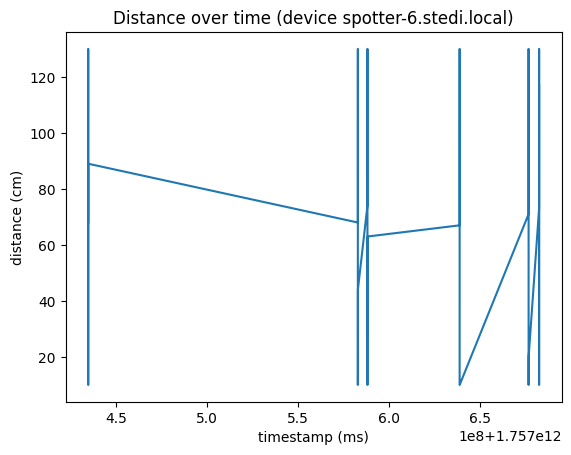

In [0]:
# Small sample for a simple line plot of distances over time for one device
import pandas as pd
import matplotlib.pyplot as plt
sample_device = features.select("device_id").first()["device_id"]
pdf = (dm_clean
.filter(F.col("device_id")==sample_device)
.orderBy("ts_ms")
.limit(1000)
.select("ts_ms","distance_cm")
.toPandas())
plt.figure()
plt.plot(pdf["ts_ms"], pdf["distance_cm"])
plt.title(f"Distance over time (device {sample_device})")
plt.xlabel("timestamp (ms)")
plt.ylabel("distance (cm)")
plt.show()

# Reflection
______________________________________________________________________
This assignment was confusing for the bulk of it; the original instructions had an incompatible syntax that required rewriting and AI help to fix swaths of it, which did not aid me in my confusion, but rather aided my confusion against me.
However, seeing the cleaned up data, I have to say I believe I can see a usage for even just the averages every day; alternatively, a trend tracker for each step and how hard it was could be incredibly useful to track endurance for even such a simple balance exercise as this.